In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! read data from files --!

data_path = '../../data/delay/detuning_24-03-2025_15-54_2'
data_frame = pd.read_csv(data_path, skiprows=23, dtype=np.float32, sep='\t', decimal=',')
detuning_data = torch.from_numpy(data_frame.to_numpy())

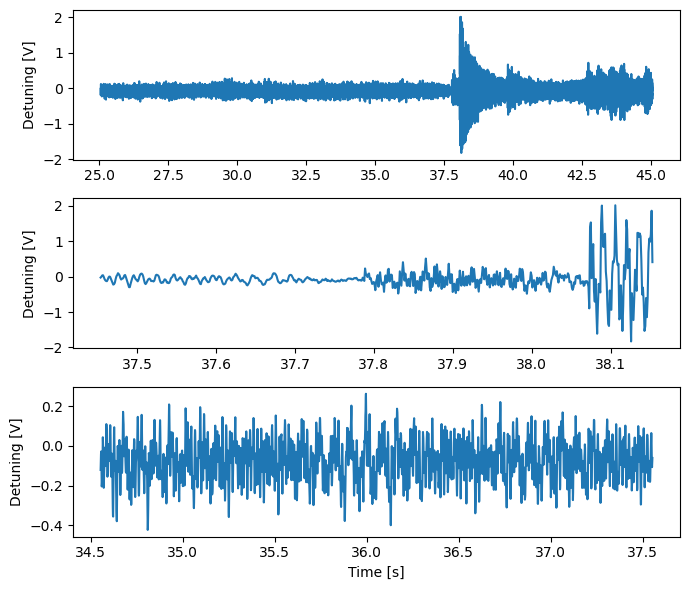

In [3]:
# --! display detuning data in time domain --!

plt.figure(figsize=(7,6))
plt.subplot(3,1,1)
plt.plot(detuning_data[:, 0], detuning_data[:, 1])
plt.ylabel('Detuning [V]')

plt.subplot(3,1,2)
plt.plot(detuning_data[12_400:13_100, 0], detuning_data[12_400:13_100, 1])
plt.ylabel('Detuning [V]')

plt.subplot(3,1,3)
plt.plot(detuning_data[9_500:12_500, 0], detuning_data[9_500:12_500, 1])
plt.ylabel('Detuning [V]')
plt.xlabel('Time [s]')

plt.tight_layout()
plt.show()


In [4]:
# --! save raw detuning data to file --!

detuning_raw = np.expand_dims(detuning_data[:18_000, [1]], axis=0)

# --! there may be other stationary regions, so make a list
detuning_raw = np.split(detuning_raw, 9, axis=1)

def cat_control(detuning):
    """ Concatenates non-active control and mask dimensions to an uncontrolled detuning signal. """
    control = np.zeros_like(detuning)
    mask = np.zeros_like(control)
    return np.concatenate([detuning, control, mask], axis=-1)

datasaved = True

if datasaved:
    savedata = np.concatenate([cat_control(d) for d in detuning_raw], axis=0)
    print(f'raw data saved with a shape {savedata.shape}')
    savedir = '../../data/kalman'
    utils_data.write_datafile(f'{savedir}/tesla_meas_raw', savedata)

raw data saved with a shape (9, 2000, 3)


In [5]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--dataset_id', 'kind-detuning-raw',
        '--file_dir', '../../data/kalman',
        '--file_name', 'tesla_meas',
        '--data_nsample', '2000',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 3, "cos": 3}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
    ]
)

dataset = utils_data.dataset_factory().create_dataset(args)
model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

# --! FIXME!
model._fit_dataset = dataset

In [6]:
train_loader, _, _ = dataset.load(data_type='stat')
model.eval()

model(
  (stationary): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=144, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=1728, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=18, out_features=6, bias=False)
    (mod_mean): Linear(in_features=6, out_features=6, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=108, bias=True

In [7]:
# --! filter data using KIND model --!

res_max = 6e-1
truth_stat = []
truth_trans = []

with torch.no_grad():
    for back, fore in train_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model.stationary(back)
        stat = model_output[0]

        res = torch.squeeze(torch.mean((truth[:, :, [0]] - stat)**2, dim=1, keepdim=False))
        label = res < res_max

        selected_truth_stat = truth[label]
        selected_truth_trans = truth[~label]

        if len(selected_truth_stat) > 0:
            truth_stat.append(selected_truth_stat)

        if len(selected_truth_trans) > 0:
            truth_trans.append(selected_truth_trans)

truth_stat = torch.cat(truth_stat, dim=0)
print(f'inf > stationary filtered data has a shape of {truth_stat.shape}')
truth_trans = torch.cat(truth_trans, dim=0)
print(f'inf > transient filtered data has a shape of {truth_trans.shape}')


inf > stationary filtered data has a shape of torch.Size([1752, 144, 3])
inf > transient filtered data has a shape of torch.Size([11611, 144, 3])


In [8]:
# --! save filtered data --!

datasaved = True
if datasaved:
    savedir = '../../data/kalman'
    utils_data.write_datafile(f'{savedir}/tesla_meas_stat', truth_stat)
    utils_data.write_datafile(f'{savedir}/tesla_meas_trans', truth_trans)